Características utilizadas:
- sepal length (cm)
- sepal width (cm)
- petal length (cm)
- petal width (cm)

Clases:
- setosa
- versicolor
- virginica

RESULTADOS DEL MODELO
Exactitud: 93.33%

Reporte de clasificación:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.83      1.00      0.91        10
   virginica       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30

Matriz de confusión:
[[10  0  0]
 [ 0 10  0]
 [ 0  2  8]]

DATOS DE LA NUEVA FLOR
Ingresa las medidas en centímetros.

Largo del sépalo: 23
Ancho del sépalo: 12
Largo del pétalo: 4
Ancho del pétalo: 5

PREDICCIÓN
Especie estimada: virginica

Probabilidades:
setosa: 20.00%
versicolor: 0.00%
virginica: 80.00%

Modelo guardado como: modelo_iris_knn.pkl


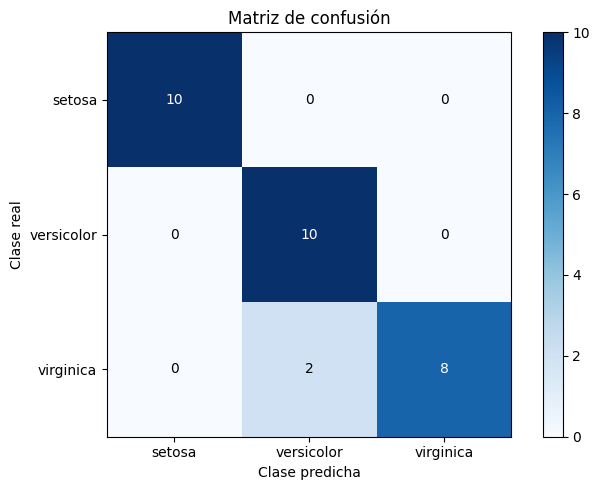

In [1]:
import joblib
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


# ==========================================
# 1. Cargar el conjunto de datos Iris
# ==========================================

iris = load_iris()

X = iris.data
y = iris.target

nombres_caracteristicas = iris.feature_names
nombres_flores = iris.target_names

print("Características utilizadas:")
for caracteristica in nombres_caracteristicas:
    print(f"- {caracteristica}")

print("\nClases:")
for clase in nombres_flores:
    print(f"- {clase}")


# ==========================================
# 2. Separar datos de entrenamiento y prueba
# ==========================================

X_entrenamiento, X_prueba, y_entrenamiento, y_prueba = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


# ==========================================
# 3. Crear el modelo KNN
# ==========================================

modelo = Pipeline([
    ("escalador", StandardScaler()),
    ("knn", KNeighborsClassifier(
        n_neighbors=5,
        weights="uniform",
        metric="euclidean"
    ))
])


# ==========================================
# 4. Entrenar el modelo
# ==========================================

modelo.fit(X_entrenamiento, y_entrenamiento)


# ==========================================
# 5. Evaluar el modelo
# ==========================================

predicciones = modelo.predict(X_prueba)

precision = accuracy_score(y_prueba, predicciones)

print("\nRESULTADOS DEL MODELO")
print("=====================")
print(f"Exactitud: {precision:.2%}")

print("\nReporte de clasificación:")
print(classification_report(
    y_prueba,
    predicciones,
    target_names=nombres_flores
))

matriz = confusion_matrix(y_prueba, predicciones)

print("Matriz de confusión:")
print(matriz)


# ==========================================
# 6. Solicitar datos de una nueva flor
# ==========================================

print("\nDATOS DE LA NUEVA FLOR")
print("======================")
print("Ingresa las medidas en centímetros.\n")

try:
    largo_sépalo = float(input("Largo del sépalo: "))
    ancho_sépalo = float(input("Ancho del sépalo: "))
    largo_pétalo = float(input("Largo del pétalo: "))
    ancho_pétalo = float(input("Ancho del pétalo: "))
except ValueError:
    print("Debes ingresar valores numéricos válidos.")
    exit()


flor_nueva = [[
    largo_sépalo,
    ancho_sépalo,
    largo_pétalo,
    ancho_pétalo
]]


# ==========================================
# 7. Realizar la predicción
# ==========================================

prediccion = modelo.predict(flor_nueva)[0]
probabilidades = modelo.predict_proba(flor_nueva)[0]

nombre_prediccion = nombres_flores[prediccion]

print("\nPREDICCIÓN")
print("==========")
print(f"Especie estimada: {nombre_prediccion}")

print("\nProbabilidades:")
for nombre, probabilidad in zip(nombres_flores, probabilidades):
    print(f"{nombre}: {probabilidad:.2%}")


# ==========================================
# 8. Guardar el modelo
# ==========================================

nombre_archivo = "modelo_iris_knn.pkl"

joblib.dump(modelo, nombre_archivo)

print(f"\nModelo guardado como: {nombre_archivo}")


# ==========================================
# 9. Visualizar la matriz de confusión
# ==========================================

plt.figure(figsize=(7, 5))

plt.imshow(matriz, cmap="Blues")
plt.title("Matriz de confusión")
plt.colorbar()

plt.xticks(
    range(len(nombres_flores)),
    nombres_flores
)

plt.yticks(
    range(len(nombres_flores)),
    nombres_flores
)

plt.xlabel("Clase predicha")
plt.ylabel("Clase real")

for fila in range(len(matriz)):
    for columna in range(len(matriz)):
        plt.text(
            columna,
            fila,
            matriz[fila, columna],
            ha="center",
            va="center",
            color="white" if matriz[fila, columna] > matriz.max() / 2 else "black"
        )

plt.tight_layout()
plt.show()